# GraphAllocBench — Metric Visualization (Problem 2b)

Generates three paper-ready panels illustrating HV Ratio, PNDS, and Ordering Score on Problem 2b (the local-optima-trap problem). Intended as subfigures in paper Figure 1.

**Run from the `examples/` directory.**

In [1]:
import sys, pathlib
notebook_dir = pathlib.Path.cwd()
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))
print('Working directory:', notebook_dir)

Working directory: /Users/zhiheng/Desktop/Projects/GraphAllocBench/graphallocbench/examples


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import spearmanr
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.indicators.hv import HV

from graphallocbench.city_env import CityPlannerEnv
from graphallocbench.evaluation import run_experiments, get_analytical_objectives

# ── Paper-ready style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'pdf.fonttype': 42,    # embed TrueType fonts in PDF
    'ps.fonttype': 42,
    'svg.fonttype': 'path', # convert text to paths in SVG (no font deps, renders anywhere)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ColorBrewer Set2 (matches existing plots in the codebase)
C_TEAL   = '#66c2a5'
C_ORANGE = '#fc8d62'
C_BLUE   = '#8da0cb'
C_GREY   = '#aaaaaa'
C_DARK   = '#333333'

OUT_DIR = Path('data/figure1_panels')
OUT_DIR.mkdir(parents=True, exist_ok=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
# ── Environment & model ───────────────────────────────────────────────────
env = CityPlannerEnv('config/problems/problem_2b.yml')
MODEL_PATH = 'models/GraphAllocBench-Problem2b/arch-0/problem_2b/0/model_step_1000000.zip'

print(f'Problem  : {env.config_name}')
print(f'Objectives: {env.n_objectives},  Demands: {env.demand_count}')
print(f'Resources : {env.avail_resources}')

Problem  : problem_2b
Objectives: 2,  Demands: 5
Resources : [10, 10]


In [4]:
# ── Collect predicted objective vectors (Das-Dennis preference grid) ───────
N_PARTITIONS = 12
preferences_dd = get_reference_directions('das-dennis', env.n_objectives, n_partitions=N_PARTITIONS)

print(f'Running {len(preferences_dd)} preference evaluations …')
predicted_objs, _ = run_experiments(
    env=env, model_path=MODEL_PATH,
    preferences=preferences_dd, random_seed=42,
)

# Ideal analytical Pareto front (cached)
ideal_objs = get_analytical_objectives(env=env)

print(f'Predicted shape : {predicted_objs.shape}')
print(f'Ideal Pareto    : {ideal_objs.shape}')

Running 13 preference evaluations …
Predicted shape : (13, 2)
Ideal Pareto    : (12, 2)


In [5]:
# ── Helper utilities ───────────────────────────────────────────────────────

def non_dominated_mask(objectives: np.ndarray) -> np.ndarray:
    """Boolean mask: True where a solution is non-dominated."""
    indices = NonDominatedSorting().do(-objectives, only_non_dominated_front=True)
    mask = np.zeros(len(objectives), dtype=bool)
    mask[indices] = True
    return mask


def hv_value(objectives: np.ndarray) -> float:
    """Hypervolume (maximisation, reference just below origin)."""
    ref = np.full(objectives.shape[1], 1e-3)
    return HV(ref_point=ref)(-objectives)


def hv_polygon(pts: np.ndarray):
    """Staircase polygon vertices for the HV dominated region (ref at origin).
    pts: 2-D array of Pareto-optimal points, will be sorted by x ascending.
    Returns (x_verts, y_verts) for plt.fill().
    """
    pts = pts[pts[:, 0].argsort()]          # sort by x ascending (y descending)
    vx = [0.0, 0.0]
    vy = [0.0, pts[0, 1]]
    for i, (px, py) in enumerate(pts):
        vx.append(px);  vy.append(py)
        if i < len(pts) - 1:
            vx.append(px);  vy.append(pts[i + 1, 1])  # step down
    vx.append(pts[-1, 0]);  vy.append(0.0)
    return np.array(vx), np.array(vy)


# Pre-compute non-dominated subset of predictions
nd_mask   = non_dominated_mask(predicted_objs)
nd_pred   = predicted_objs[nd_mask]
dom_pred  = predicted_objs[~nd_mask]

hv_pred  = hv_value(predicted_objs)
hv_ideal = hv_value(ideal_objs)
hv_ratio = hv_pred / hv_ideal
pnds     = nd_mask.mean()

print(f'HV ratio : {hv_ratio:.3f}')
print(f'PNDS     : {pnds:.3f}  ({nd_mask.sum()} / {len(nd_mask)} non-dominated)')

HV ratio : 0.533
PNDS     : 0.846  (11 / 13 non-dominated)


## Panel 1 — Hypervolume Ratio

The **shaded teal region** is the hypervolume dominated by the ideal Pareto front.  
The **shaded orange region** is the hypervolume dominated by the predicted solutions.  
HV ratio = area(predicted) / area(ideal) — the gap between the two shaded regions is the loss.

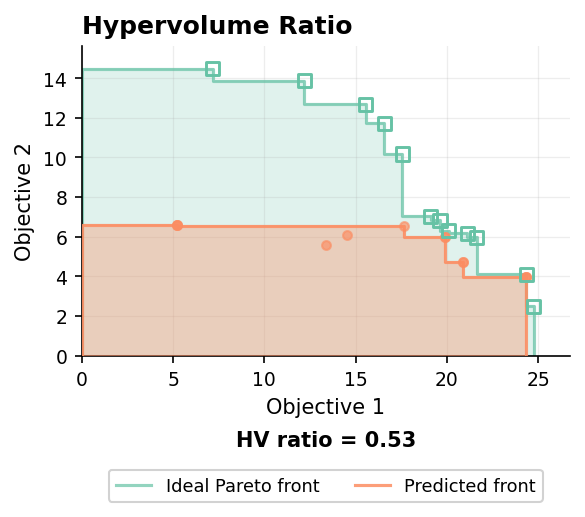

Saved panel_hv_ratio.pdf / .png / .svg


In [6]:
fig, ax = plt.subplots(figsize=(4.0, 5.5))

ix, iy = hv_polygon(ideal_objs)
ax.fill(ix, iy, color=C_TEAL,   alpha=0.20, zorder=1)
ax.plot(ix, iy, color=C_TEAL,   alpha=0.70, lw=1.5, label='Ideal Pareto front', zorder=2)
px, py = hv_polygon(nd_pred)
ax.fill(px, py, color=C_ORANGE, alpha=0.35, zorder=3)
ax.plot(px, py, color=C_ORANGE, alpha=0.85, lw=1.5, label='Predicted front', zorder=4)
ax.scatter(ideal_objs[:, 0], ideal_objs[:, 1],
           marker='s', s=40, facecolors='none', edgecolors=C_TEAL, lw=1.4, zorder=5)
ax.scatter(predicted_objs[:, 0], predicted_objs[:, 1],
           marker='o', s=18, color=C_ORANGE, alpha=0.65, zorder=4)

ax.set_title('Hypervolume Ratio', loc='left', fontsize=12, fontweight='bold')
ax.set_xlabel('Objective 1')
ax.set_ylabel('Objective 2')
ax.grid(True, alpha=0.22, lw=0.6)
ax.set_xlim(0, ideal_objs[:, 0].max() * 1.08)
ax.set_ylim(0, ideal_objs[:, 1].max() * 1.08)

ax.text(0.5, -0.24, f'HV ratio = {hv_ratio:.2f}',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.34),
          ncol=2, framealpha=0.88, fontsize=8.5)

plt.tight_layout(rect=[0, 0.22, 1, 1])
for ext in ('pdf', 'png', 'svg'):
    fig.savefig(OUT_DIR / f'panel_hv_ratio.{ext}', bbox_inches='tight')
plt.show()
print('Saved panel_hv_ratio.pdf / .png / .svg')

## Panel 2 — Proportion of Non-Dominated Solutions (PNDS)

Green circles = predicted solutions that are **non-dominated** (form part of an approximate Pareto front).  
Grey × = **dominated** predictions — at least one other predicted point is better in every objective.  
PNDS = fraction of predictions that are non-dominated.

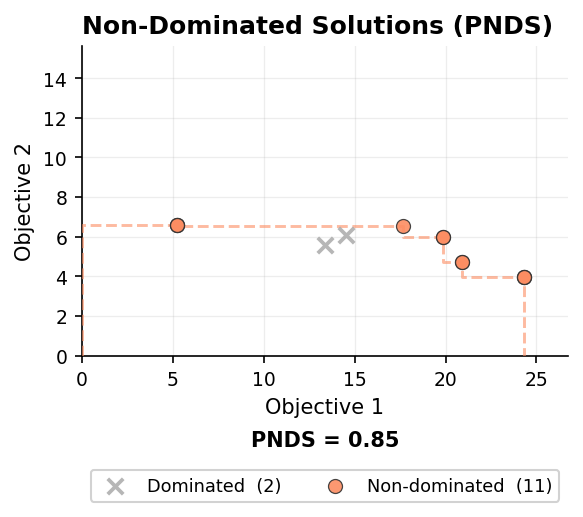

Saved panel_pnds.pdf / .png / .svg


In [7]:
fig, ax = plt.subplots(figsize=(4.0, 5.5))

x_lim = ideal_objs[:, 0].max() * 1.08
y_lim = ideal_objs[:, 1].max() * 1.08

pnx, pny = hv_polygon(nd_pred)
ax.plot(pnx, pny, color=C_ORANGE, alpha=0.60, lw=1.4, ls='--', zorder=3)

if len(dom_pred) > 0:
    ax.scatter(dom_pred[:, 0], dom_pred[:, 1],
               marker='x', s=55, color=C_GREY, lw=1.8, alpha=0.85,
               label=f'Dominated  ({(~nd_mask).sum()})', zorder=4)
ax.scatter(nd_pred[:, 0], nd_pred[:, 1],
           marker='o', s=45, color=C_ORANGE, edgecolors=C_DARK, lw=0.6, alpha=0.90,
           label=f'Non-dominated  ({nd_mask.sum()})', zorder=5)

ax.set_title('Non-Dominated Solutions (PNDS)', loc='left', fontsize=12, fontweight='bold')
ax.set_xlabel('Objective 1')
ax.set_ylabel('Objective 2')
ax.grid(True, alpha=0.22, lw=0.6)
ax.set_xlim(0, x_lim)
ax.set_ylim(0, y_lim)

ax.text(0.5, -0.24, f'PNDS = {pnds:.2f}',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.34),
          ncol=2, framealpha=0.88, fontsize=8.5)

plt.tight_layout(rect=[0, 0.22, 1, 1])
for ext in ('pdf', 'png', 'svg'):
    fig.savefig(OUT_DIR / f'panel_pnds.{ext}', bbox_inches='tight')
plt.show()
print('Saved panel_pnds.pdf / .png / .svg')

## Panel 3 — Ordering Score

We sweep the preference weight $w_0$ from 0 to 1 (with $w_1 = 1 - w_0$) and record the resulting objective values.

- **Top**: $J_0$ should rise and $J_1$ should fall as $w_0$ increases (preference obedience).  
  Dashed lines show ideal monotone responses.
- **Bottom**: Spearman rank correlation $\rho$ between each objective and its expected monotone direction,  
  normalised to $[0,1]$. OS = average of both.

In [8]:
# ── Sweep w₁ from 0 → 1  (w₂ = 1 − w₁) ─────────────────────────────────
N_SWEEP = 21
w1_vals = np.linspace(0.0, 1.0, N_SWEEP)
sweep_prefs = np.column_stack([w1_vals, 1.0 - w1_vals])

sweep_objs, _ = run_experiments(
    env=env, model_path=MODEL_PATH,
    preferences=sweep_prefs, random_seed=42,
)
J1 = sweep_objs[:, 0]
J2 = sweep_objs[:, 1]

# Spearman: Obj i should correlate positively with its own weight
# J1 should rise with w₁;  J2 should rise with w₂ = 1 − w₁
rho1_raw = spearmanr(w1_vals,       J1).statistic
rho2_raw = spearmanr(1.0 - w1_vals, J2).statistic

rho1_score = (rho1_raw + 1) / 2
rho2_score = (rho2_raw + 1) / 2
os_val     = (rho1_score + rho2_score) / 2

print(f'ρ₁ = {rho1_raw:.3f}  (score {rho1_score:.3f})')
print(f'ρ₂ = {rho2_raw:.3f}  (score {rho2_score:.3f})')
print(f'OS = {os_val:.3f}')

ρ₁ = 0.976  (score 0.988)
ρ₂ = 0.973  (score 0.987)
OS = 0.987


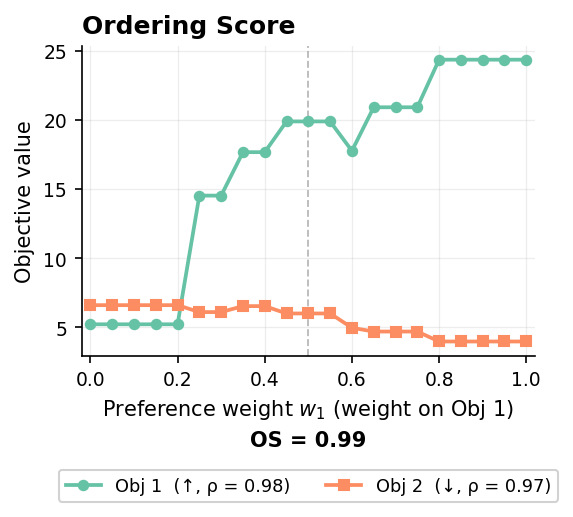

Saved panel_ordering.pdf / .png / .svg


In [9]:
fig, ax = plt.subplots(figsize=(4.0, 5.5))

ax.axvline(0.5, color='#bbbbbb', lw=0.9, ls='--', zorder=1)
ax.plot(w1_vals, J1, 'o-', color=C_TEAL,   ms=4.5, lw=1.8, zorder=3,
        label=f'Obj 1  (↑, ρ = {rho1_raw:.2f})')
ax.plot(w1_vals, J2, 's-', color=C_ORANGE, ms=4.5, lw=1.8, zorder=3,
        label=f'Obj 2  (↓, ρ = {rho2_raw:.2f})')

ax.set_title('Ordering Score', loc='left', fontsize=12, fontweight='bold')
ax.set_xlabel('Preference weight $w_1$ (weight on Obj 1)')
ax.set_ylabel('Objective value')
ax.grid(True, alpha=0.22, lw=0.6)
ax.set_xlim(-0.02, 1.02)

ax.text(0.5, -0.24, f'OS = {os_val:.2f}',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.34),
          ncol=2, framealpha=0.88, fontsize=8.5)

plt.tight_layout(rect=[0, 0.22, 1, 1])
for ext in ('pdf', 'png', 'svg'):
    fig.savefig(OUT_DIR / f'panel_ordering.{ext}', bbox_inches='tight')
plt.show()
print('Saved panel_ordering.pdf / .png / .svg')

## Combined 3-panel figure

Assembles all three panels side-by-side for a quick sanity check. The individual PDFs above are the canonical outputs for inclusion in the paper.

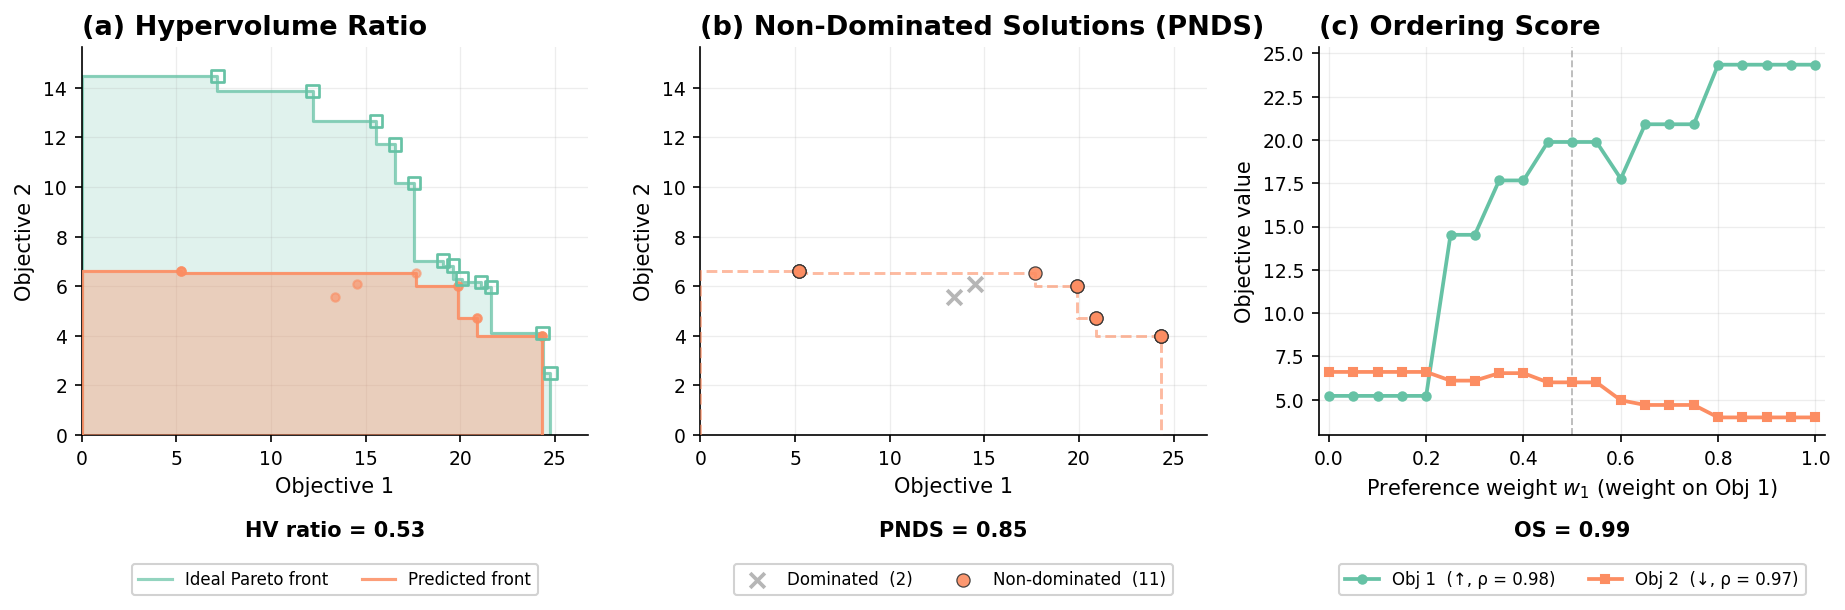

All panels saved to /Users/zhiheng/Desktop/Projects/GraphAllocBench/graphallocbench/examples/data/figure1_panels


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 6.0))

x_lim = ideal_objs[:, 0].max() * 1.08
y_lim = ideal_objs[:, 1].max() * 1.08

# ─── Panel A: HV Ratio ────────────────────────────────────────────────────
ax = axes[0]
ix, iy = hv_polygon(ideal_objs)
ax.fill(ix, iy, color=C_TEAL,   alpha=0.20, zorder=1)
ax.plot(ix, iy, color=C_TEAL,   alpha=0.70, lw=1.5, label='Ideal Pareto front', zorder=2)
px, py = hv_polygon(nd_pred)
ax.fill(px, py, color=C_ORANGE, alpha=0.35, zorder=3)
ax.plot(px, py, color=C_ORANGE, alpha=0.85, lw=1.5, label='Predicted front', zorder=4)
ax.scatter(ideal_objs[:, 0], ideal_objs[:, 1],
           marker='s', s=35, facecolors='none', edgecolors=C_TEAL, lw=1.3, zorder=5)
ax.scatter(predicted_objs[:, 0], predicted_objs[:, 1],
           marker='o', s=16, color=C_ORANGE, alpha=0.60, zorder=4)
ax.set_xlabel('Objective 1'); ax.set_ylabel('Objective 2')
ax.grid(True, alpha=0.22, lw=0.6); ax.set_xlim(0, x_lim); ax.set_ylim(0, y_lim)
ax.set_title('(a) Hypervolume Ratio', loc='left', fontsize=13, fontweight='bold')
ax.text(0.5, -0.22, f'HV ratio = {hv_ratio:.2f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=10, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.31),
          ncol=2, fontsize=8, framealpha=0.88)

# ─── Panel B: PNDS ───────────────────────────────────────────────────────
ax = axes[1]
pnx, pny = hv_polygon(nd_pred)
ax.plot(pnx, pny, color=C_ORANGE, alpha=0.60, lw=1.4, ls='--', zorder=3)
if len(dom_pred) > 0:
    ax.scatter(dom_pred[:, 0], dom_pred[:, 1],
               marker='x', s=50, color=C_GREY, lw=1.8, alpha=0.85,
               label=f'Dominated  ({(~nd_mask).sum()})', zorder=4)
ax.scatter(nd_pred[:, 0], nd_pred[:, 1],
           marker='o', s=40, color=C_ORANGE, edgecolors=C_DARK, lw=0.6, alpha=0.90,
           label=f'Non-dominated  ({nd_mask.sum()})', zorder=5)
ax.set_xlabel('Objective 1'); ax.set_ylabel('Objective 2')
ax.grid(True, alpha=0.22, lw=0.6); ax.set_xlim(0, x_lim); ax.set_ylim(0, y_lim)
ax.set_title('(b) Non-Dominated Solutions (PNDS)', loc='left', fontsize=13, fontweight='bold')
ax.text(0.5, -0.22, f'PNDS = {pnds:.2f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=10, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.31),
          ncol=2, fontsize=8, framealpha=0.88)

# ─── Panel C: Ordering Score ─────────────────────────────────────────────
ax = axes[2]
ax.axvline(0.5, color='#bbbbbb', lw=0.9, ls='--', zorder=1)
ax.plot(w1_vals, J1, 'o-', color=C_TEAL,   ms=4, lw=1.8, zorder=3,
        label=f'Obj 1  (↑, ρ = {rho1_raw:.2f})')
ax.plot(w1_vals, J2, 's-', color=C_ORANGE, ms=4, lw=1.8, zorder=3,
        label=f'Obj 2  (↓, ρ = {rho2_raw:.2f})')
ax.set_xlabel('Preference weight $w_1$ (weight on Obj 1)')
ax.set_ylabel('Objective value')
ax.grid(True, alpha=0.22, lw=0.6); ax.set_xlim(-0.02, 1.02)
ax.set_title('(c) Ordering Score', loc='left', fontsize=13, fontweight='bold')
ax.text(0.5, -0.22, f'OS = {os_val:.2f}',
        transform=ax.transAxes, ha='center', va='top', fontsize=10, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.31),
          ncol=2, fontsize=8, framealpha=0.88)

for a in axes:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.20, 1, 1])
for ext in ('pdf', 'png', 'svg'):
    fig.savefig(OUT_DIR / f'figure1_combined.{ext}', bbox_inches='tight')
plt.show()
print(f'All panels saved to {OUT_DIR.resolve()}')